### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

Tracking agent behavior with logging, analytics, and debugging.
Transforming prompts, tool selection, and output formatting.
Adding retries, fallbacks, and early termination logic.
Applying rate limits, guardrails, and PII detection.

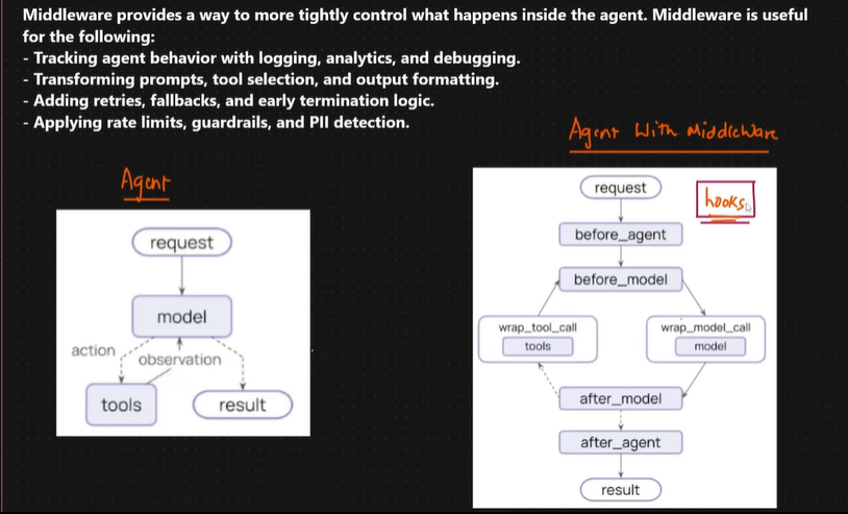

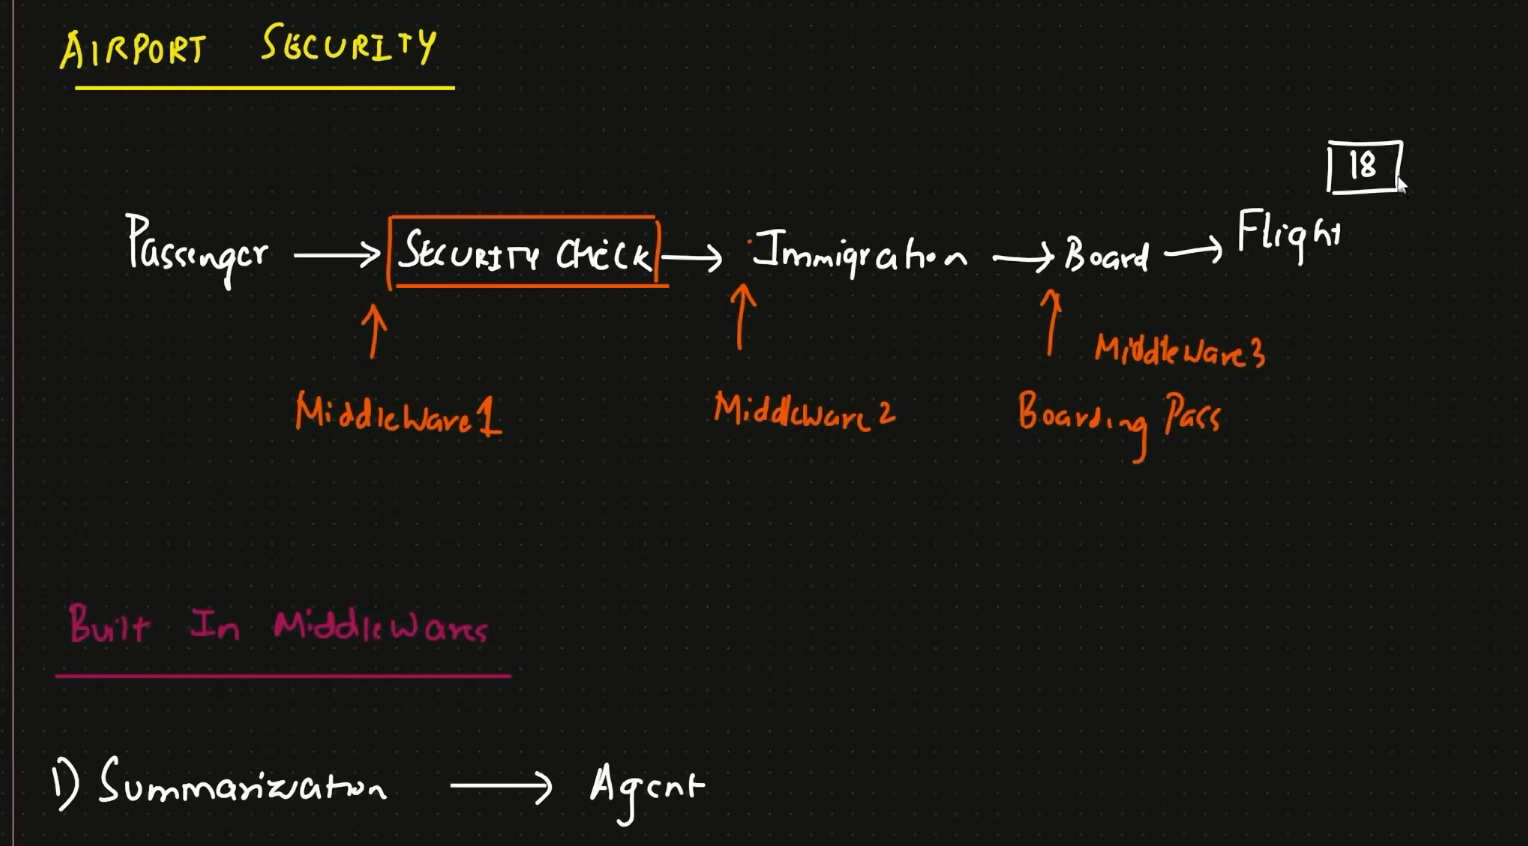

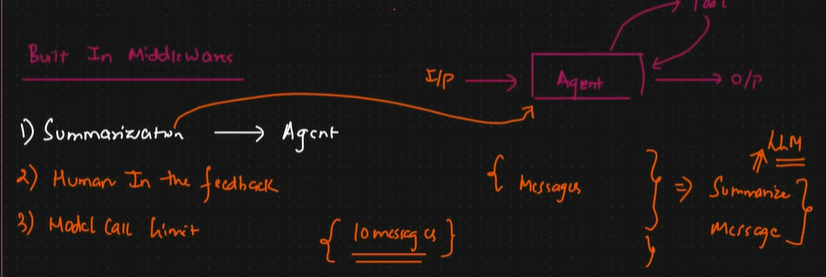

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

### Summarization Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing
older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [9]:
from langchain.agents.middleware import SummarizationMiddleware
from langchain.agents import create_agent
from langchain.agents.middleware import summarization
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

### Messagebased summarization
agent=create_agent(
    model="google_genai:gemini-3.6-flash",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="google_genai:gemini-3.6-flash",
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

In [10]:
### Run with thread id
config={"configurable":{"thread_id":"test-1"}}

# Alternative test data
questions = [
"What is 2+2?",
"What is 10*5?",
"What is 100/4?",
"What is 15-7?",
"What is 3*3?",
"What is 4+4?",

]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='d39c6f36-83ac-4d78-ab98-0344eb2eee05'), AIMessage(content=[{'type': 'text', 'text': '2 + 2 = 4.', 'extras': {'signature': 'EoADCv0CARFNMg8nT6HE3vEeMwVAMKQI4xSDAxd67NXy5ClTWOal4xXbYJ18UNikJdZ5CFm5H/eX6MS4Cou6WxDIrmLLJz5ufWjzN4xpdbx0VlE93+ELXeH5Kfd/Vdr0y2dCQWSeWhyIENoLF+d4b3y6/ExSN2/u1hs/8GZVSE6v/DU8MYNvECUMM9y9+VB43eh4C2ICf1Y5ZhoQbWYp1fuWwdpCvqhYPv1CIePZ6at0i3k+HAqrR1aTLyvss1r0v2QB9LYuWXWLndjK935hCcL/MsNfpPB4s3ZfMM4cgGjOOdrfZfM6g7metWv0wwWIG+gQuHurFJn2/UMbXSaEWVrvkLb7mQcN3BDZxJvURMuC+tTwH8TABfkC0kRUr120yV+XJKVYtPa1WBkIZmh9YcB1AZOhXq9ak1hQddgjrO+7tzgyyZ9yWIeg/lD5tnCVpPL5MHtClp/wYl7zYdzAsDxHrA9e2THPEjlHOAPhwo/oILS3oQ5BXLdzZ0YEVZGFUixV'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a09cb5-b24a-7c82-814a-e4521cddbeba-0', tool_calls=[], invalid_tool_calls=[]

In [12]:
from langchain import messages
from cryptography.x509 import certificate_transparency
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens. """
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent=create_agent(
    model="google_genai:gemini-3.6-flash",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="google_genai:gemini-3.6-flash",
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)
config={"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens (messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars = 1 token

In [14]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~565 tokens, 7 messages
[HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\n\nThe user wants to find and potentially book hotel accommodations across requested destinations (previously Paris and London, most recently Tokyo).\n\n## SUMMARY\n\n- The user previously inquired about Paris and London hotels.\n- Hotel search for Tokyo (`search_hotels(city="Tokyo")`) was performed and returned three options:\n  1. **Grand Hotel**: 5 stars, $350/night (spa, pool, gym)\n  2. **City Inn**: 4 stars, $180/night (business center)\n  3. **Budget Stay**: 3 stars, $75/night (free Wi-Fi)\n- The Tokyo hotel options have been presented to the user.\n\n## ARTIFACTS\n\nNone\n\n## NEXT STEPS\n\n- Await user response for hotel selection, booking request, specific preferences, or additional destination inquiries.', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='e3f303ae-4375-4d0d-9b24-62af3ffd06db'), HumanMessage(content='Find hotels i

GoogleRateLimitError: Error calling model 'gemini-3.6-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-3.6-flash\nPlease retry in 30.245324029s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier',

### Fraction

### Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the
following:

- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

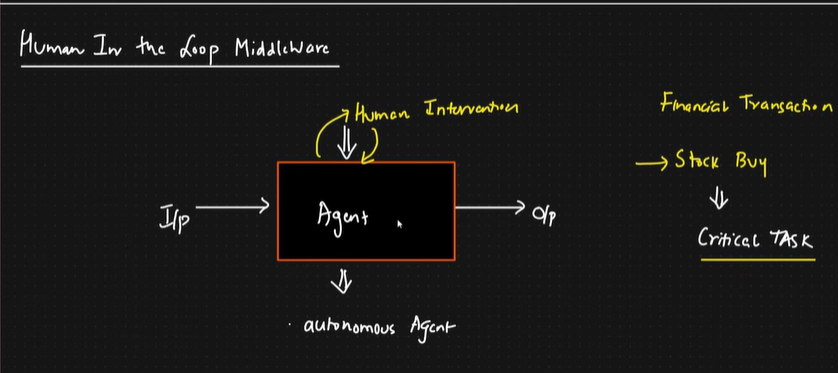

In [15]:
from openai.types.beta import beta_response_code_interpreter_call_in_progress_event
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [17]:
agent=create_agent(
    model="google_genai:gemini-3.6-flash",
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
) 

In [18]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [19]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='e9539bac-f46d-42d1-8c2a-e579d9799ab8'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"subject": "Hello", "body": "How are you?", "recipient": "john@test.com"}'}, '__gemini_function_call_thought_signatures__': {'call_7656082': 'Er0ECroEARFNMg8i5S3JEeIWFCA/OGZADLQfr0AkEWfi02HCs9I2Jv+98/OgskPmOEb7mzufiH+BPyk7D1HIkmw57KamB5UvIM5XIUAr1/k2yBG2/XPzcvqhrAZIUrzx9HmyGAFLsBi0Sk0Azi52/8coNt2ticu6VKl9l82sdhayv21dHSQrrwxidTtA06TevbYd01n++ebEuA3a9C4/+Y1RDoEQUSziHdWs6mU1dK7M7UjiBdXzSglJYzDg3maBEXS2UT3NoFZBvrHhg4idb8qN820k7JHom8uPgL/Xd1RGHbJe8dzD8T3mmYPOwsbM0VeWxe/eCjfIvCMbCstVX/ud0GkrVDjNI8IhhUpoPFrtWT5vIiyRgGXGrDH4uhZoIPM1BAMmshn8AIMQTwMo5+k0cRUKaoDBiK8zC5z2nWfFDq4+gdQzBGYAC3iojukU0Y8bofqUauTYXMqCEC9vS01CI+JMCO5e2ceOupxKFzyG6bFc4RanQGWfhYcYOYaMVjzZ+91l0Pxh7DqPP3YOOZwPhRsBCFfBKGqaIEsv6TTe

In [22]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("Paused! Approving ... ")
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ), 
        config=config
    )
    print(f"Result: {result['messages'][-1].content}")

Paused! Approving ... 
Result: [{'type': 'text', 'text': 'The email has been successfully sent to john@test.com with the subject "Hello" and body "How are you?".', 'extras': {'signature': 'EqgBCqUBARFNMg/h7QoVNVyFbmq2wXFSb1Pged37ZnEbYCvqohP/V5o+jzq6mdLupr8XDV8YeJwqtmYy7p8PqqBeuxfX7SjVJX5KbJl6PJExu4W25ZtsUp2EmUgZAVVn57lfMLLlOKbAanRUniSPmw736mulGsB4Fxtq0eJsfIUrECFf+d2VFX3Ly45vxIA+7Jos53Sof2IujgE++Kyc2Xst2zh5UMAH1DVV'}}]


In [23]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='e9539bac-f46d-42d1-8c2a-e579d9799ab8'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"subject": "Hello", "body": "How are you?", "recipient": "john@test.com"}'}, '__gemini_function_call_thought_signatures__': {'call_7656082': 'Er0ECroEARFNMg8i5S3JEeIWFCA/OGZADLQfr0AkEWfi02HCs9I2Jv+98/OgskPmOEb7mzufiH+BPyk7D1HIkmw57KamB5UvIM5XIUAr1/k2yBG2/XPzcvqhrAZIUrzx9HmyGAFLsBi0Sk0Azi52/8coNt2ticu6VKl9l82sdhayv21dHSQrrwxidTtA06TevbYd01n++ebEuA3a9C4/+Y1RDoEQUSziHdWs6mU1dK7M7UjiBdXzSglJYzDg3maBEXS2UT3NoFZBvrHhg4idb8qN820k7JHom8uPgL/Xd1RGHbJe8dzD8T3mmYPOwsbM0VeWxe/eCjfIvCMbCstVX/ud0GkrVDjNI8IhhUpoPFrtWT5vIiyRgGXGrDH4uhZoIPM1BAMmshn8AIMQTwMo5+k0cRUKaoDBiK8zC5z2nWfFDq4+gdQzBGYAC3iojukU0Y8bofqUauTYXMqCEC9vS01CI+JMCO5e2ceOupxKFzyG6bFc4RanQGWfhYcYOYaMVjzZ+91l0Pxh7DqPP3YOOZwPhRsBCFfBKGqaIEsv6TTe

### Reject

In [24]:
from openai.types.beta import beta_response_code_interpreter_call_in_progress_event
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent=create_agent(
    model="google_genai:gemini-3.6-flash",
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
) 

In [25]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [26]:
from langgraph.types import Command
# Step 2: Reject 
if "__interrupt__" in result:
    print("Paused! Approving ... ")
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ), 
        config=config
    )
    print(f"Result: {result['messages'][-1].content}")

Paused! Approving ... 
Result: [{'type': 'text', 'text': 'The request to send the email was cancelled. Please let me know if you would like me to try again or if you need help with anything else!', 'extras': {'signature': 'EoICCv8BARFNMg8sLESg3Ah/MrKnZW2g7XjHAXCJMjjeOqsgB+FTkRnZp8mUSe1o6rS+UkB2J9cYO6X7fCjQuvx/0oaP97wj9Cm6r7kbypdAEw3kwKQcLjCR/clIw4eGK6EfBZq545ZPpnJ1kjv9ZScbX620OiyfQOaCcGUuxMfLXmy3QH5Wz+eMFTHikI1IAzQifc/yxJw4yYu+55PWguJykZm0UOyC1xz2KmkoirUU/vscmtRa/XnW7XfPERip7cAcWlHJuXBJb2AuRXvDOOUzkVHy2rj5zeoAb2v0vrm8x11t+OMuN/ijvGHnAC8DaW6Lv/U2GqQnx+2+mkyDRcYMjfY7'}}]


In [27]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='505a0b56-8195-43bd-9459-c1de456227f3'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"subject": "Hello", "body": "How are you?", "recipient": "john@test.com"}'}, '__gemini_function_call_thought_signatures__': {'call_6510389': 'EsQFCsEFARFNMg9Tot966Oi2NExX01B5LLvrDUA2pVnaa8V19S0kXjhiig5doCk8pngi5i9ZqPaCZ6OFeuXm2ZlNyRQMv/BI29/05A0HRUDzHAuLVri7EKHyVKO3m9AYq75IJB0e75pb7RVwQswOhuiDIn5ni2A6INYKUFr+A51uB98tIKWZbuABZSPdpt+MKaMO3VyQsW4vh5aU7/2Ft/4DpHKbd0w8GdwpbXESnnD1RsM09dAwhVTJ+V85ZmcL+1BN5k0xHBxXXO9LcSXRzFCYEyzyHH78dIXVRit3OQYZrYe9UsKNkyqLGHPLG4SkK/zcS+CPf7WFDA6XcRvNCLddqVUPA3fjWvWwtDO6slgBpEATYKZMJnqykT5gzpRPgVu0Qb/ERXkL6h0AyzqkIDXQAQoTIjhyrObJTukjj+PHqYwCqg72OMY0D9FFnHVWwwtwWV5MlREl4gIsbIFq0iBS2KCPzlUsFiSkHiCz2Ey8M5gdDtIlstjbAmxhUbXJB4O+Sr5EpmSSVf/44D2g/yqtOX3/g5gDr6KqvWzbdWEb